In [1]:
from functools import reduce
from collections import defaultdict
from dataclasses import dataclass

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
import sys
sys.path.append(r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE\evaluate')

In [3]:
import eval_20Minuten
import eval_CStance
import eval_FOMC
import eval_MeetingBank
import eval_NumGLUE_ds
import eval_NumGLUE_cm
import eval_PapyrusF
import eval_Py150
import eval_ScienceQA

## Loading predictions

In [4]:
base_path = r"C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE"

# dataset_names = ['20Minuten', 'FOMC', 'MeetingBank', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'Lima', 'NumGLUE-cm', 'Py150']  # All benchmarks
All_dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds', 'ScienceQA', 'C-STANCE', 'NumGLUE-cm', 'Py150']                       # Benchmarks in use
dataset_names = ['20Minuten', 'FOMC', 'NumGLUE-ds']

preds_dict = defaultdict(lambda: dict())

Загрузка Raw

In [5]:
# for dataset_name in dataset_names:
#     path = rf"C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\TRACE\preds\Raw\{dataset_name}.bin"

#     with open(path, 'rb') as f:
#         preds_dict['Raw'][dataset_name] = pickle.load(file=f)

Загрузка дообученных

In [6]:
@dataclass
class ExperimentRun:
    model_name: str
    adapter_name: str = None
    cfg: int = None
    seq: int = None
    seq_task: str = None

    def get_base_pth(self) -> str:
        path = rf"{base_path}\preds\{self.model_name}"
        if self.adapter_name:
            path += f"-{self.adapter_name}"
        if self.cfg:
            path += f"-cfg{self.cfg}"
        if self.seq:
            path += f"\seq-{self.seq}"
        if self.seq_task:
            path += f"\{self.seq_task}"
        # path = rf"{base_path}\preds\{self.model_name}-{self.adapter_name}-cfg{self.cfg}\seq-{self.seq}\{self.seq_task}"

        return path
    
    def get_run_name(self) -> str:
        if self.adapter_name:
            run_name = self.adapter_name
        else:
            run_name = self.model_name
            
        if self.cfg:
            run_name += f"-cfg{self.cfg}"
        if self.seq:
            run_name += f"-{self.seq}"
        if self.seq_task:
            run_name += f"-{self.seq_task}"
        # run_name = f"{self.adapter_name}-cfg{self.cfg}-{self.seq}-{self.seq_task}"

        return run_name

In [7]:
experiments = [
    ExperimentRun(model_name='Raw')
]

experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task=seq_task)
    for seq_task in All_dataset_names
]

experiments += [
    ExperimentRun(model_name='Llama-32-1b', adapter_name='GSOFT', cfg=1, seq=1, seq_task=seq_task)
    for seq_task in All_dataset_names
]

experiments

[ExperimentRun(model_name='Raw', adapter_name=None, cfg=None, seq=None, seq_task=None),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='20Minuten'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='FOMC'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='NumGLUE-ds'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='ScienceQA'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='C-STANCE'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='NumGLUE-cm'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='LoRA', cfg=1, seq=1, seq_task='Py150'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='GSOFT', cfg=1, seq=1, seq_task='20Minuten'),
 ExperimentRun(model_name='Llama-32-1b', adapter_name='GSOFT', cfg=1, seq=1, seq_task='FOMC'),
 ExperimentRun(model_name='Llama

In [8]:
experiments[1].get_run_name()

'LoRA-cfg1-1-20Minuten'

In [9]:
for experiment in experiments:
    run_name = experiment.get_run_name()
    print(f"Loading {run_name}")

    for dataset_name in dataset_names:
        path = rf"{experiment.get_base_pth()}\{dataset_name}.bin"

        with open(path, 'rb') as f:
            preds_dict[run_name][dataset_name] = pickle.load(file=f)

Loading Raw
Loading LoRA-cfg1-1-20Minuten
Loading LoRA-cfg1-1-FOMC
Loading LoRA-cfg1-1-NumGLUE-ds
Loading LoRA-cfg1-1-ScienceQA
Loading LoRA-cfg1-1-C-STANCE
Loading LoRA-cfg1-1-NumGLUE-cm
Loading LoRA-cfg1-1-Py150
Loading GSOFT-cfg1-1-20Minuten
Loading GSOFT-cfg1-1-FOMC
Loading GSOFT-cfg1-1-NumGLUE-ds
Loading GSOFT-cfg1-1-ScienceQA
Loading GSOFT-cfg1-1-C-STANCE
Loading GSOFT-cfg1-1-NumGLUE-cm
Loading GSOFT-cfg1-1-Py150


In [11]:
preds_dict['GSOFT-cfg1-1-FOMC']['FOMC']

,prompt,answer,text,text_wa_answer,model_pred
0,What is the monetary policy stance for the fol...,B,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' B. Hawkish. The text desc...
1,What is the monetary policy stance for the fol...,B,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. neutral. The text desc...
2,What is the monetary policy stance for the fol...,A,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. neutral. The text desc...
3,What is the monetary policy stance for the fol...,C,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. neutral. The text desc...
4,What is the monetary policy stance for the fol...,C,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. Neutral. The text desc...
...,...,...,...,...,...
491,What is the monetary policy stance for the fol...,C,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. neutral. The text desc...
492,What is the monetary policy stance for the fol...,A,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. Neutral. The text desc...
493,What is the monetary policy stance for the fol...,B,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. neutral. The text desc...
494,What is the monetary policy stance for the fol...,C,<|begin_of_text|><|start_header_id|>system<|en...,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': ' C. neutral. The text desc...


### Evaluation

In [12]:
eval_functions = {
    '20Minuten': eval_20Minuten.eval, 
    'FOMC': eval_FOMC.eval, 
    'NumGLUE-ds': eval_NumGLUE_ds.eval, 
    'ScienceQA': eval_ScienceQA.eval, 
    'C-STANCE': eval_CStance.eval, 
    'NumGLUE-cm': eval_NumGLUE_cm.eval,
    'Py150': eval_Py150.eval,
}

def calc_scores(preds_dfs):
    eval_scores = {}

    for dataset_name in dataset_names:
        print(f"Running for {dataset_name}")
        preds_df = preds_dfs[dataset_name]

        correct_answers = list(preds_df['answer'])
        model_preds = [pred['generated_text'].strip() for pred in preds_df['model_pred']]

        if dataset_name != '20Minuten':
            eval_scores[dataset_name] = eval_functions[dataset_name](model_preds, correct_answers)
        else:
            input_seq = list(preds_df['prompt'])
            eval_scores[dataset_name] = eval_functions[dataset_name](input_seq, model_preds, correct_answers)
    
    return eval_scores

In [13]:
scores_dict = {
    run_name: calc_scores(preds_dfs)
    for run_name, preds_dfs in preds_dict.items()
}

Running for 20Minuten


c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
c:\python_venvs\ml_venv\Lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.

Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds
Running for 20Minuten
Running for FOMC
Running for NumGLUE-ds


In [14]:
print(scores_dict.keys())

dict_keys(['Raw', 'LoRA-cfg1-1-20Minuten', 'LoRA-cfg1-1-FOMC', 'LoRA-cfg1-1-NumGLUE-ds', 'LoRA-cfg1-1-ScienceQA', 'LoRA-cfg1-1-C-STANCE', 'LoRA-cfg1-1-NumGLUE-cm', 'LoRA-cfg1-1-Py150', 'GSOFT-cfg1-1-20Minuten', 'GSOFT-cfg1-1-FOMC', 'GSOFT-cfg1-1-NumGLUE-ds', 'GSOFT-cfg1-1-ScienceQA', 'GSOFT-cfg1-1-C-STANCE', 'GSOFT-cfg1-1-NumGLUE-cm', 'GSOFT-cfg1-1-Py150'])


**Raw**

In [15]:
for dataset_name in dataset_names:
    eval_score = scores_dict['Raw'][dataset_name]

    print(f"{dataset_name}:\n    ", '\n    '.join(f"{key}: {val}" for key, val in eval_score.items()))
    print("\n")

20Minuten:
     bleu-1: 0.09321426467245647
    bleu-4: 0.0069805684871051136
    rouge-L: 0.16469634531039795
    sari: ({'sari': 36.157578040864465},)


FOMC:
     accuracy: 0.2762096774193548


NumGLUE-ds:
     accuracy: 0.2553846153846154




**20Minuten-FT**

In [16]:
for dataset_name in dataset_names:
    eval_score = scores_dict['LoRA-cfg1-1-20Minuten'][dataset_name]

    print(f"{dataset_name}:\n    ", '\n    '.join(f"{key}: {val}" for key, val in eval_score.items()))
    print("\n")

20Minuten:
     bleu-1: 0.029456139086622733
    bleu-4: 0.0038944776080578752
    rouge-L: 0.21243217874649198
    sari: ({'sari': 37.073241316737466},)


FOMC:
     accuracy: 0.25


NumGLUE-ds:
     accuracy: 0.20307692307692307




**FOMC-FT**

In [17]:
for dataset_name in dataset_names:
    eval_score = scores_dict['LoRA-cfg1-1-FOMC'][dataset_name]

    print(f"{dataset_name}:\n    ", '\n    '.join(f"{key}: {val}" for key, val in eval_score.items()))
    print("\n")

20Minuten:
     bleu-1: 0.031602524814431536
    bleu-4: 0.0038149988507536047
    rouge-L: 0.19470815575005052
    sari: ({'sari': 36.13384575972735},)


FOMC:
     accuracy: 0.5625


NumGLUE-ds:
     accuracy: 0.033846153846153845




### Visualization

**FOMC accuracy**

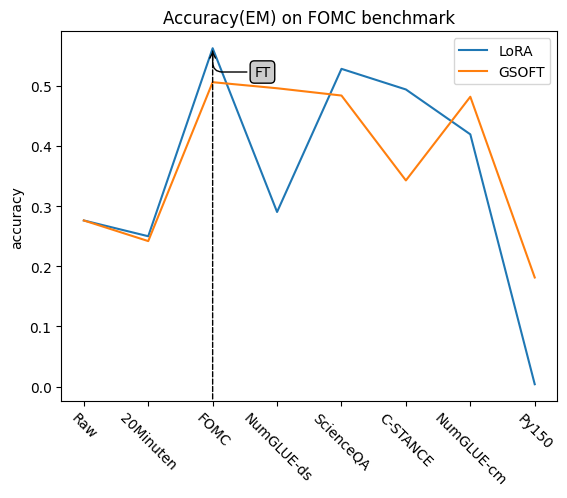

In [21]:
bench_name = 'FOMC'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(All_dataset_names))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

bbox = dict(boxstyle ="round", fc ="0.8") 
arrowprops = dict( 
    arrowstyle = "->", 
    connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
) 
  
offset = 72
plt.annotate(
    text='FT', 
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
    xytext =(30, -20), 
    textcoords ='offset points', 
    bbox = bbox, arrowprops = arrowprops
) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, -0.025), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

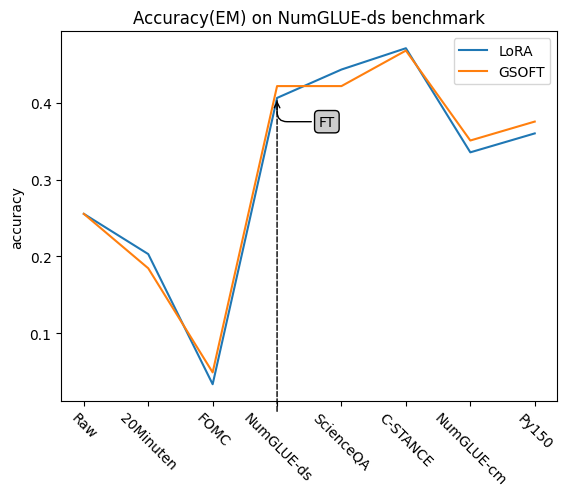

In [24]:
bench_name = 'NumGLUE-ds'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(All_dataset_names))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

bbox = dict(boxstyle ="round", fc ="0.8") 
arrowprops = dict( 
    arrowstyle = "->", 
    connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
) 
  
offset = 72
plt.annotate(
    text='FT', 
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
    xytext=(30, -20), 
    textcoords ='offset points', 
    bbox = bbox, arrowprops = arrowprops
) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, -0.005), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

In [25]:
bench_name = 'ScienceQA'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(All_dataset_names))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

bbox = dict(boxstyle ="round", fc ="0.8") 
arrowprops = dict( 
    arrowstyle = "->", 
    connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
) 
  
offset = 72
plt.annotate(
    text='FT', 
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
    xytext =(30, -20), 
    textcoords ='offset points', 
    bbox = bbox, arrowprops = arrowprops
) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, -0.0005), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

KeyError: 'ScienceQA'

Text(0.5, 1.0, 'Accuracy(EM) on C-STANCE benchmark')

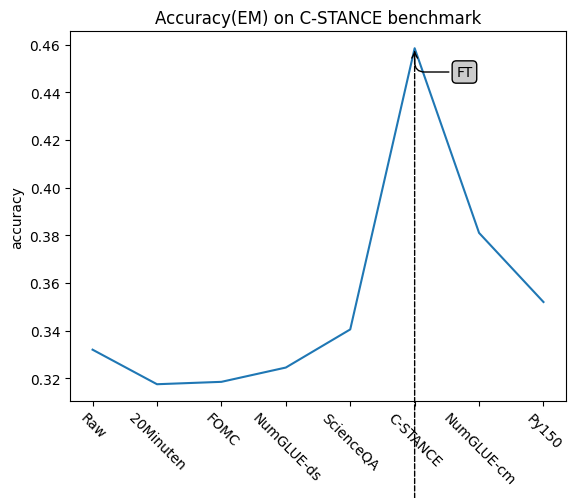

In [ ]:
bench_name = 'C-STANCE'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(All_dataset_names))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

bbox = dict(boxstyle ="round", fc ="0.8") 
arrowprops = dict( 
    arrowstyle = "->", 
    connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
) 
  
offset = 72
plt.annotate(
    text='FT', 
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
    xytext =(30, -20), 
    textcoords ='offset points', 
    bbox = bbox, arrowprops = arrowprops
) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, -0.025), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

Text(0.5, 1.0, 'Accuracy(EM) on NumGLUE-cm benchmark')

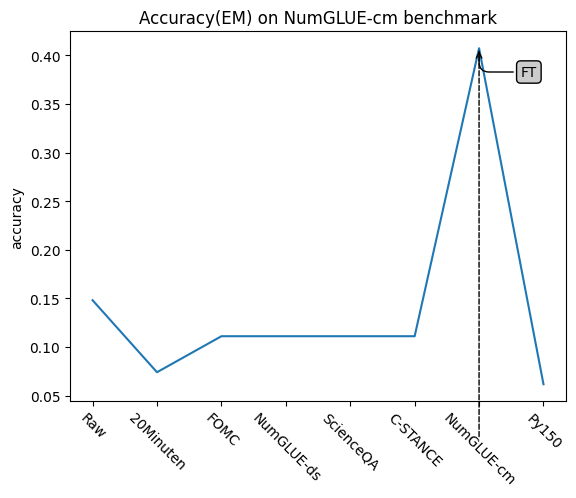

In [ ]:
bench_name = 'NumGLUE-cm'
exp_idx = min(idx for idx, exp in enumerate(experiments) if exp.seq_task == bench_name)
exp_run_name = experiments[exp_idx].get_run_name()
x_axs = range(1 + len(All_dataset_names))


plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'LoRA')],
    label='LoRA'
)

plt.plot(
    x_axs,
    [scores_dict[exp.get_run_name()][bench_name]['accuracy'] for exp in experiments if (exp.model_name == 'Raw') or (exp.adapter_name == 'GSOFT')],
    label='GSOFT'
)

bbox = dict(boxstyle ="round", fc ="0.8") 
arrowprops = dict( 
    arrowstyle = "->", 
    connectionstyle = "angle, angleA = 0, angleB = 90, rad = 10"
) 
  
offset = 72
plt.annotate(
    text='FT', 
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']), 
    xytext =(30, -20), 
    textcoords ='offset points', 
    bbox = bbox, arrowprops = arrowprops
) 

plt.annotate(
    text='',
    xy=(exp_idx, scores_dict[exp_run_name][bench_name]['accuracy']),
    xytext=(exp_idx, -0.025), xycoords='data',
    arrowprops={"arrowstyle" : "-", "linestyle" : "--"}
)

plt.xticks(
    x_axs, 
    labels=['Raw'] + [exp.seq_task for exp in experiments if exp.adapter_name == 'LoRA'], 
    rotation=-45
)

plt.ylabel('accuracy')
plt.title(f'Accuracy(EM) on {bench_name} benchmark')
plt.legend()

In [ ]:
# import json

# A_datasets = ['C-STANCE', 'FOMC', 'MeetingBank', 'Py150', 'ScienceQA', 'NumGLUE-cm', 'NumGLUE-ds', '20Minuten']
# A_epochs = [5, 3, 7, 5, 3, 5, 5, 7]


# with open('./epochs.json', 'w') as f:
#     json.dump(
#         obj={
#             A_ds: A_ep
#             for A_ds, A_ep in zip(A_datasets, A_epochs)
#         },
#         fp=f
#     )

In [ ]:
# set(A_datasets) - set(dataset_names)

In [60]:
AAA_bs = {}

for ds_name in All_dataset_names:
    if ds_name in ('Py150', '20Minuten', 'ScienceQA'):
        AAA_bs[ds_name] = 4
    else:
        AAA_bs[ds_name] = 8

import json
json.dumps(AAA_bs)

'{"20Minuten": 4, "FOMC": 8, "NumGLUE-ds": 8, "ScienceQA": 4, "C-STANCE": 8, "NumGLUE-cm": 8, "Py150": 4}'